# Pseudotime preprocessing: FAPs → Pre_adipocytes

Loads omentum and subcutaneous SVF datasets, subsets to FAPs and Pre_adipocytes,
runs Harmony integration on `common_participant`, filters out FAP subclusters not
connected to the Pre_adipocyte trajectory via PAGA, then computes non-integrated
and integrated UMAPs and diffusion pseudotime (DPT).

**Key design choices:**
- Leiden + PAGA filtering removes small FAP clusters that are disconnected from the
  Pre_adipocyte cluster — these derail DPT if left in.
- Root is the FAP with the **lowest projection** onto the FAP → Pre_adipocyte direction
  vector in diffusion space (most upstream/progenitor-like), not the centroid.

**Outputs** (written to `obesity_scRNAseq/outputs/pseudotime/`):
- `paga_overview.png` — PAGA graph used for filtering
- `umap_integration_comparison.png` — non-integrated vs Harmony
- `umap_pseudotime.png` — DPT pseudotime on Harmony UMAP
- `pseudotime_distributions.png` — density histograms by cell type / cohort / depot
- `fap_preadip_processed.h5ad` — processed object for `pseudotime_02_tradeseq.R`

## 0. Imports and settings

In [31]:
import os

import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

try:
    import harmonypy as hm
except ImportError:
    raise ImportError("Install harmonypy:  pip install harmonypy")

sc.settings.set_figure_params(dpi=100, facecolor="white", frameon=False)
%matplotlib inline

In [33]:
BASE_IN  = "/Users/willtrim/Documents/projs/Wills_analysis/obesity_scRNAseq/inputs/anndatas"
BASE_OUT = "/Users/willtrim/Documents/projs/Wills_analysis/obesity_scRNAseq/outputs/pseudotime/myo"

os.makedirs(BASE_OUT, exist_ok=True)

PALETTE = {
    "cell_type_": None,
    "cohort":     {"Healthy": "#2196F3", "Unhealthy": "#F44336"},
    "depot":      {"Omentum": "#FF9800", "Subcutaneous": "#9C27B0"},
    "sex":        {"F": "#E91E63", "M": "#00BCD4"},
}
COLORS = {
    "FAPs":           "#FF9800",
    "Pre_adipocytes": "#4CAF50",
    "Myofibroblasts": "#6e0465",
    "Healthy":        "#2196F3",
    "Unhealthy":      "#F44336",
    "Omentum":        "#FF9800",
    "Subcutaneous":   "#9C27B0",
}

## 1. Load and label datasets

In [3]:
om = sc.read_h5ad(f"{BASE_IN}/omentum_reannotated_finely_truncated.h5ad")
sq = sc.read_h5ad(f"{BASE_IN}/sq_reannotated_finely_truncated.h5ad")

om.obs["depot"] = "Omentum"
sq.obs["depot"] = "Subcutaneous"

adata_full = sc.concat(
    [om, sq], keys=["Om", "SQ"], label="dataset", merge="same", uns_merge="same"
)
print(f"Combined dataset: {adata_full.shape}")

Combined dataset: (34957, 22410)


## 2. Subset to FAPs + Pre_adipocytes

In [5]:
adata = adata_full[
    adata_full.obs["cell_type_"].isin(["FAPs", "Pre_adipocytes", "Myofibroblasts"])
].copy()

print(f"Subset shape: {adata.shape}")
adata.obs.groupby(["depot", "cell_type_"]).size().rename("n_cells").to_frame()

Subset shape: (14727, 22410)


n_cells
depot        cell_type_             
Omentum      FAPs               6787
             Myofibroblasts      697
             Pre_adipocytes     1297
Subcutaneous FAPs               4983
             Myofibroblasts      329
             Pre_adipocytes      634

## 3. Preprocessing from raw counts

Normalise → log1p → batch-aware HVG selection → scale → PCA.

In [6]:
adata.X = adata.layers["counts"].copy()
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
adata.layers["logcounts"] = adata.X.copy()

sc.pp.highly_variable_genes(
    adata, n_top_genes=3000, batch_key="common_participant",
    flavor="seurat_v3", layer="counts",
)
print(f"HVGs selected: {adata.var['highly_variable'].sum()}")

HVGs selected: 3000


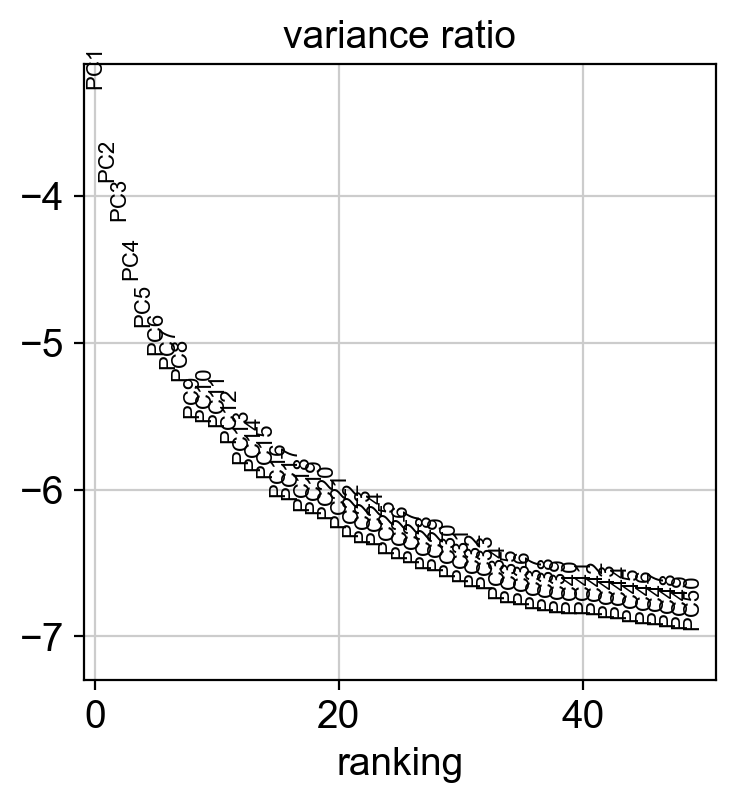

In [7]:
adata_hvg = adata[:, adata.var["highly_variable"]].copy()
sc.pp.scale(adata_hvg, max_value=10)
sc.tl.pca(adata_hvg, n_comps=50, svd_solver="arpack")
adata.obsm["X_pca"] = adata_hvg.obsm["X_pca"].copy()
adata.uns["pca"]    = adata_hvg.uns["pca"].copy()

sc.pl.pca_variance_ratio(adata, n_pcs=50, log=True)

## 4. Harmony integration on `common_participant`

In [8]:
ho = hm.run_harmony(
    adata.obsm["X_pca"].copy(),
    adata.obs[["common_participant",  "depot"]].copy(),
    vars_use=["common_participant", "depot"],
    max_iter_harmony=30,
    random_state=42,
)
adata.obsm["X_pca_harmony"] = ho.Z_corr

sc.pp.neighbors(
    adata, n_neighbors=30, n_pcs=30,
    use_rep="X_pca_harmony", key_added="neighbors_harmony",
)
print("Harmony integration done.")

2026-05-19 10:05:32,124 - harmonypy - INFO - Running Harmony (PyTorch on mps)
2026-05-19 10:05:32,125 - harmonypy - INFO -   Parameters:
2026-05-19 10:05:32,125 - harmonypy - INFO -     max_iter_harmony: 30
2026-05-19 10:05:32,126 - harmonypy - INFO -     max_iter_kmeans: 20
2026-05-19 10:05:32,126 - harmonypy - INFO -     epsilon_cluster: 1e-05
2026-05-19 10:05:32,127 - harmonypy - INFO -     epsilon_harmony: 0.0001
2026-05-19 10:05:32,127 - harmonypy - INFO -     nclust: 100
2026-05-19 10:05:32,128 - harmonypy - INFO -     block_size: 0.05
2026-05-19 10:05:32,129 - harmonypy - INFO -     lamb: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
2026-05-19 10:05:32,130 - harmonypy - INFO -     theta: [2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2.]
2026-05-19 10:05:32,131 - harmonypy - INFO -     sigma: [0.1 0.1 0.1 0.1 0.1]...
2026-05-19 10:05:32,132 - harmonypy - INFO -     verbose: True
2026-05-19 10:05:32,132 - harmonypy - INFO -     random_state: 42
2026-05-19 10:05:32,133 - harmonypy - INFO -   Data: 50

Harmony integration done.


## 6. Recompute neighbours on filtered data + non-integrated UMAP

In [9]:
# Non-integrated neighbours (unscaled PCA, for showing batch effects)
sc.pp.neighbors(adata, n_neighbors=30, n_pcs=30, key_added="neighbors_noint")
sc.tl.umap(adata, neighbors_key="neighbors_noint")
adata.obsm["X_umap_noint"] = adata.obsm["X_umap"].copy()

# Harmony-integrated neighbours
sc.pp.neighbors(
    adata, n_neighbors=30, n_pcs=30,
    use_rep="X_pca_harmony", key_added="neighbors_harmony",
)
sc.tl.umap(adata, neighbors_key="neighbors_harmony")
adata.obsm["X_umap_harmony"] = adata.obsm["X_umap"].copy()
print("UMAPs done.")

UMAPs done.


## 7. UMAP comparison: non-integrated vs Harmony

After Harmony, depot and cohort mixing should improve while cell-type structure is preserved.

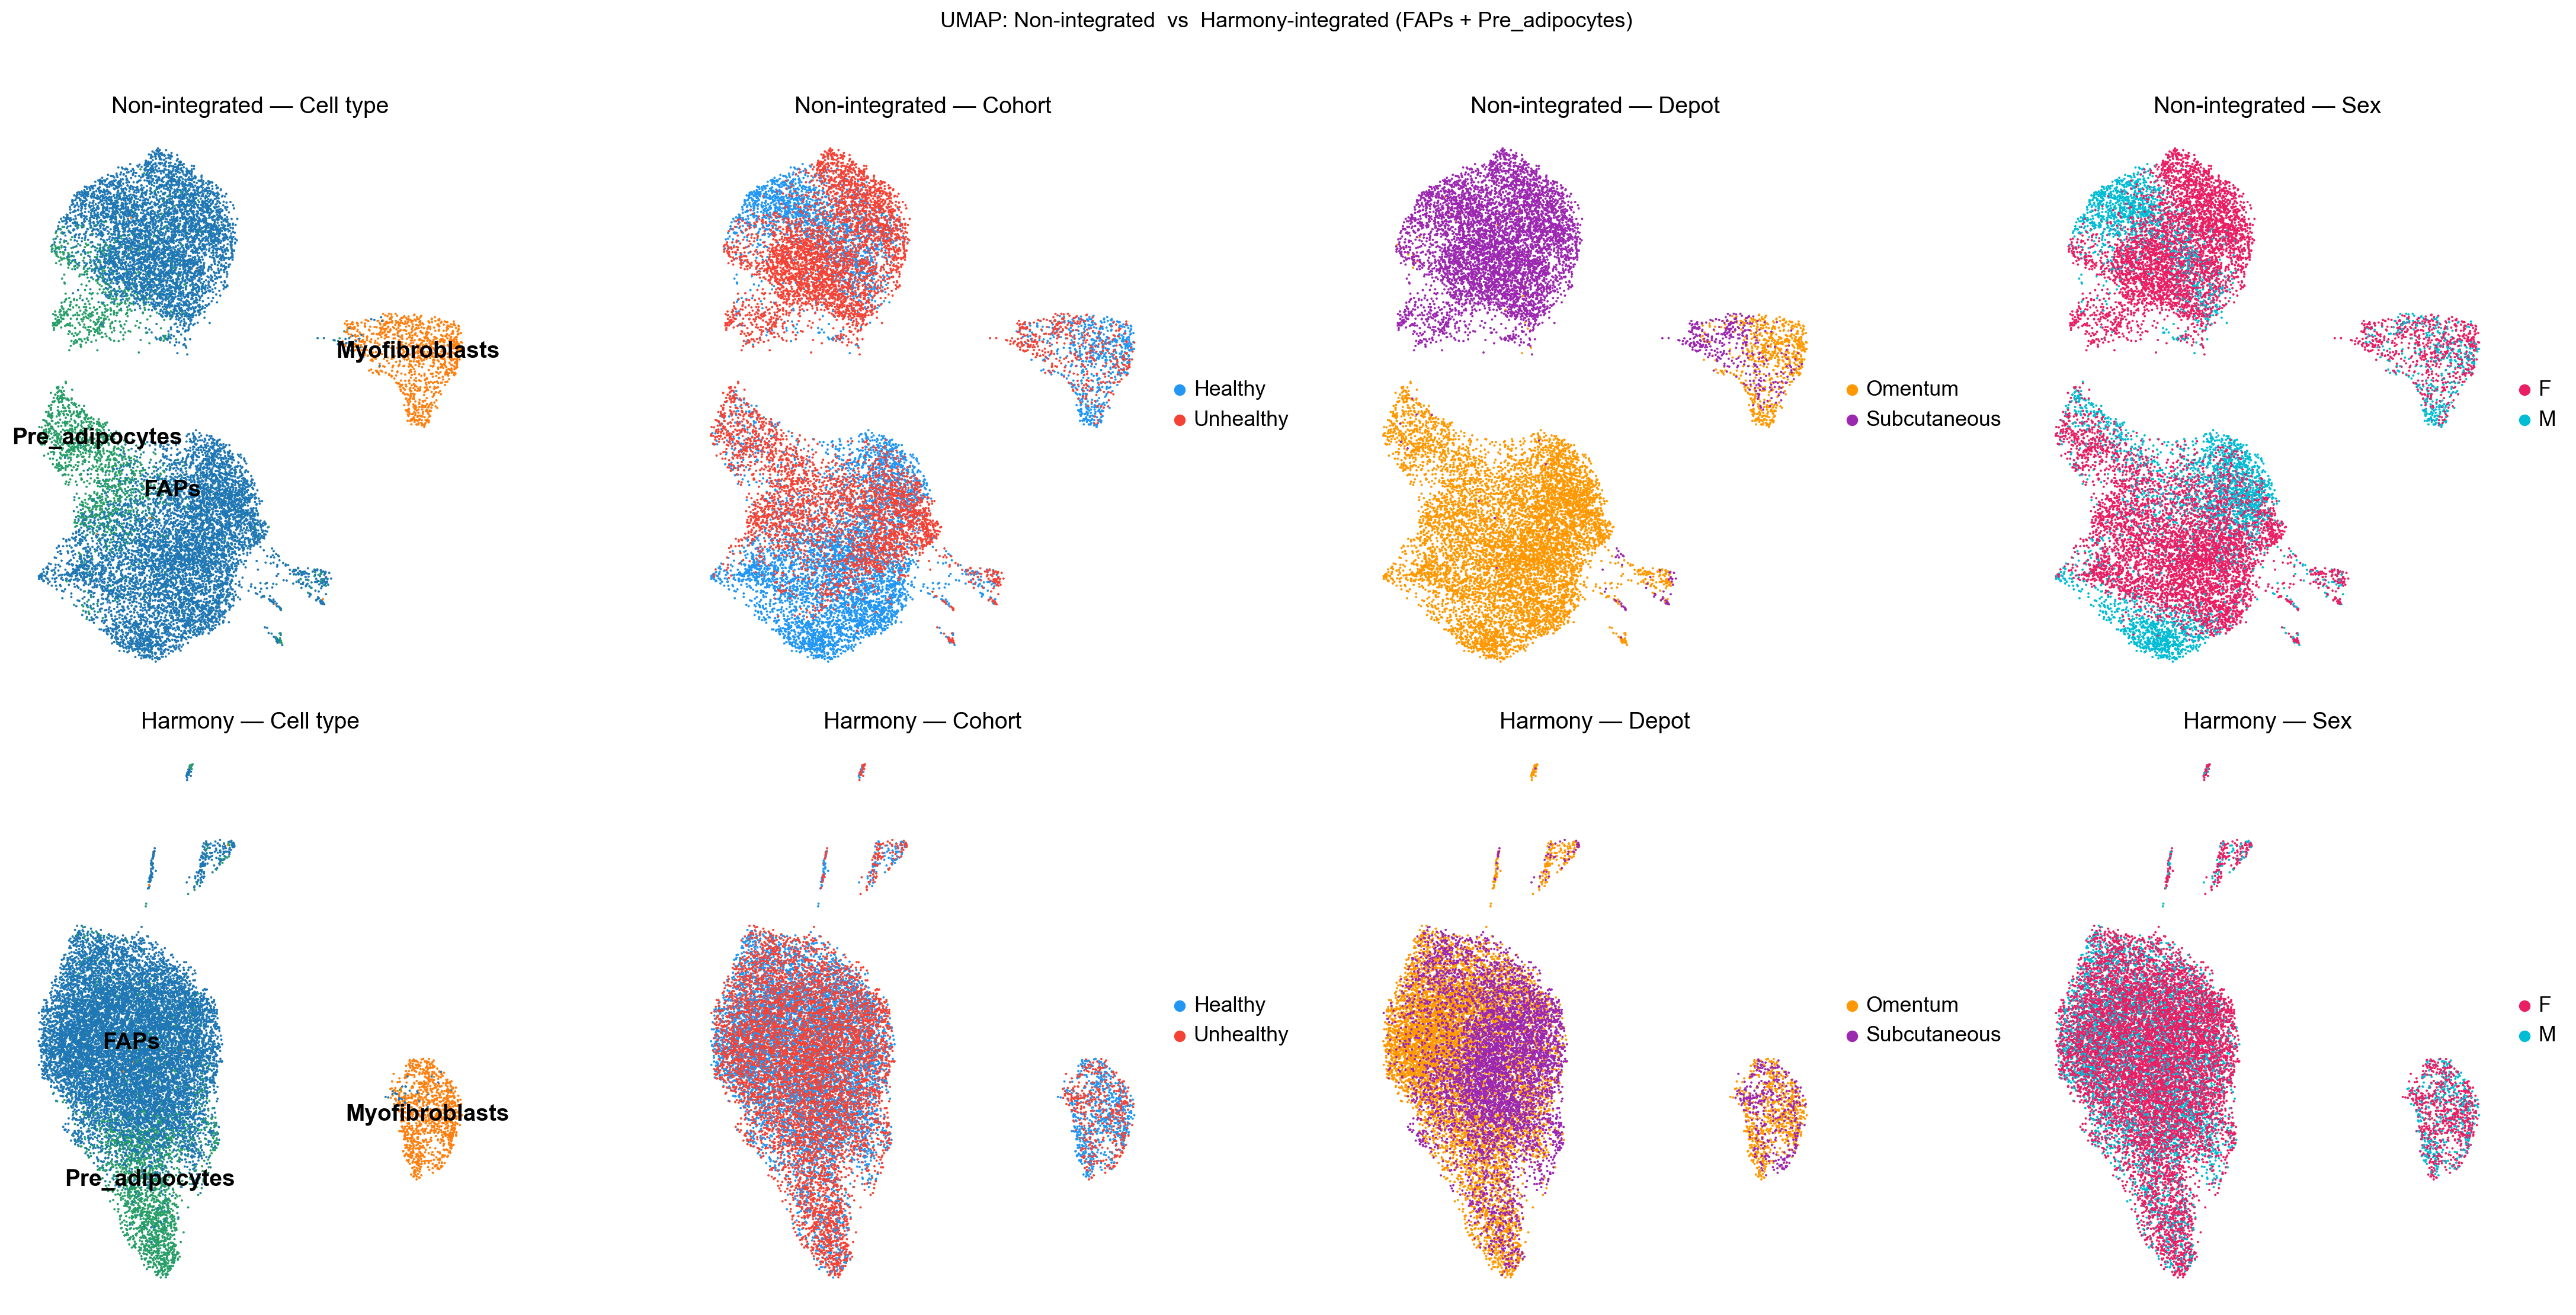

In [10]:
panels = [
    ("cell_type_", "umap_noint",   "Non-integrated — Cell type"),
    ("cohort",     "umap_noint",   "Non-integrated — Cohort"),
    ("depot",      "umap_noint",   "Non-integrated — Depot"),
    ("sex",        "umap_noint",   "Non-integrated — Sex"),
    ("cell_type_", "umap_harmony", "Harmony — Cell type"),
    ("cohort",     "umap_harmony", "Harmony — Cohort"),
    ("depot",      "umap_harmony", "Harmony — Depot"),
    ("sex",        "umap_harmony", "Harmony — Sex"),
]

fig, axes = plt.subplots(2, 4, figsize=(22, 11))
fig.suptitle("UMAP: Non-integrated  vs  Harmony-integrated (FAPs + Pre_adipocytes)",
             fontsize=13, y=1.01)

for ax, (color_by, basis, title) in zip(axes.flat, panels):
    sc.pl.embedding(
        adata, basis=basis, color=color_by, ax=ax, show=False,
        title=title, frameon=False,
        palette=PALETTE[color_by],
        legend_loc="on data" if color_by == "cell_type_" else "right margin",
        size=8,
    )

plt.tight_layout()
plt.savefig(f"{BASE_OUT}/umap_integration_comparison.pdf", bbox_inches="tight", dpi=150)
plt.savefig(f"{BASE_OUT}/umap_integration_comparison.png", bbox_inches="tight", dpi=150)
plt.show()

In [11]:
sc.tl.draw_graph(adata, neighbors_key="neighbors_harmony")

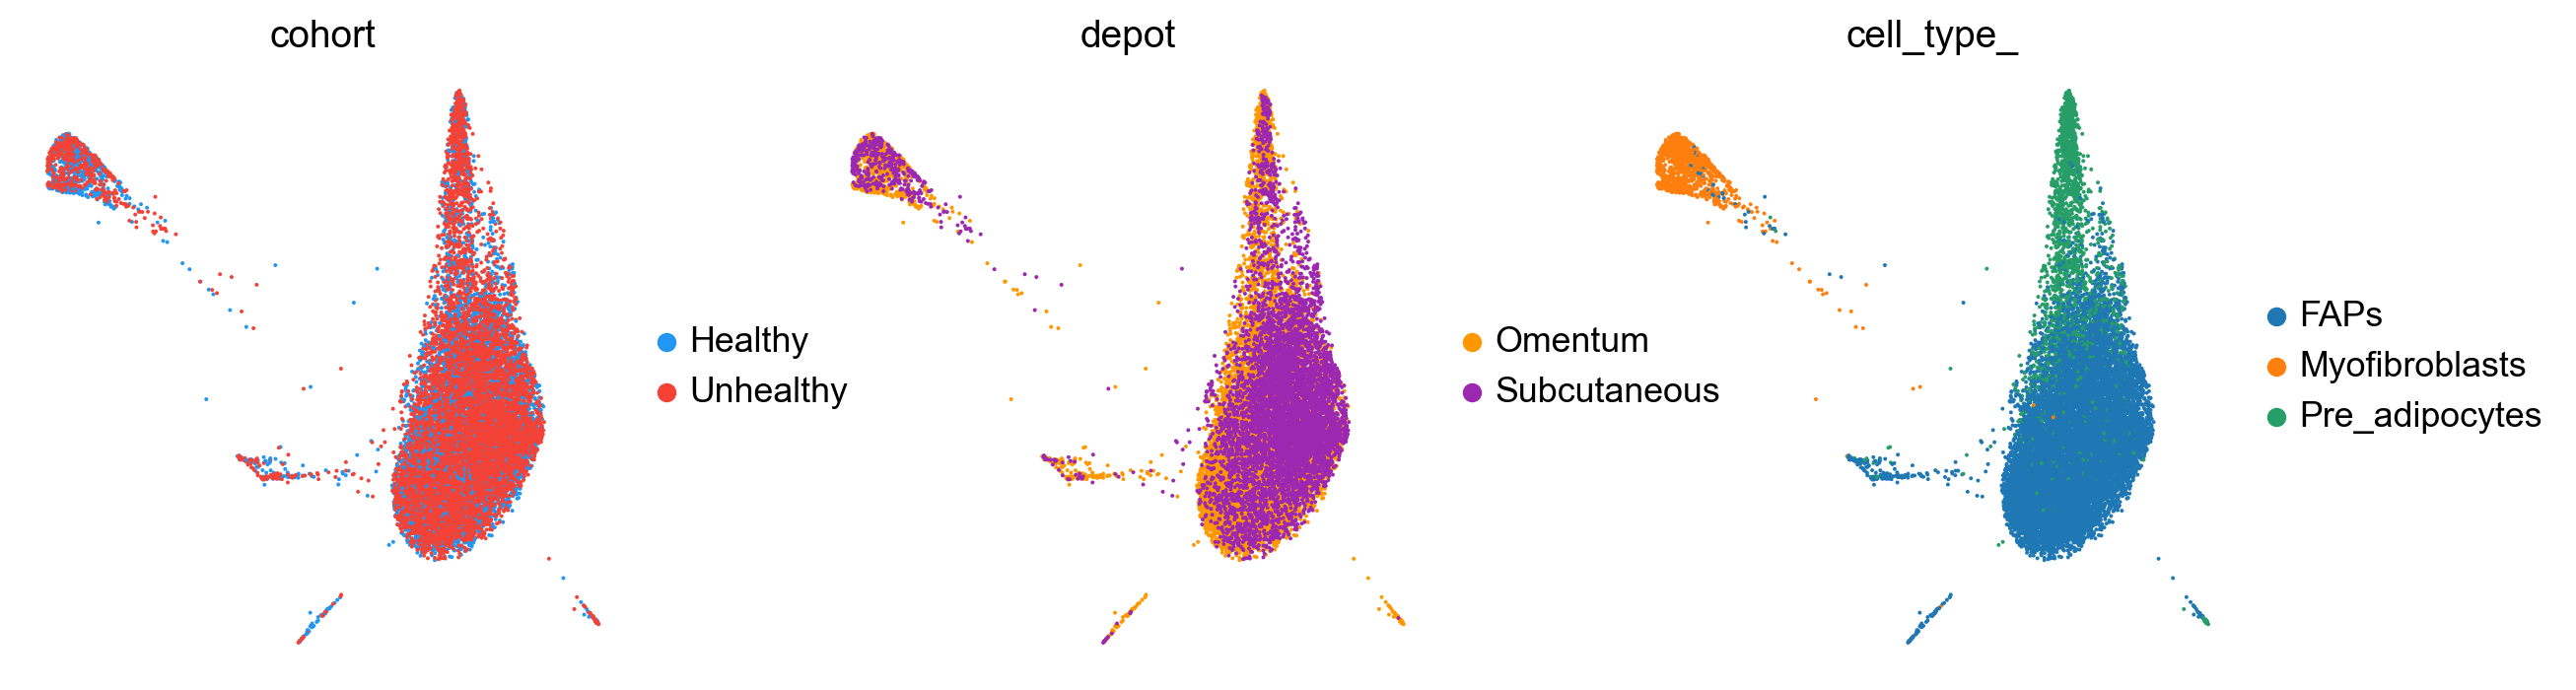

In [12]:
sc.pl.embedding(adata, basis="X_draw_graph_fa", color=["cohort", "depot", "cell_type_"])

## 5. PAGA filtering — remove FAP clusters not on the trajectory

Small, isolated FAP subclusters that are disconnected from Pre_adipocytes in the
PAGA graph will cause DPT to end there instead of at Pre_adipocytes.
We remove them here, before computing any UMAPs or pseudotime.

**Tune `LEIDEN_RESOLUTION`** if the clustering is too coarse or too fine —
the goal is to separate the main FAP body from any small outlier clusters.

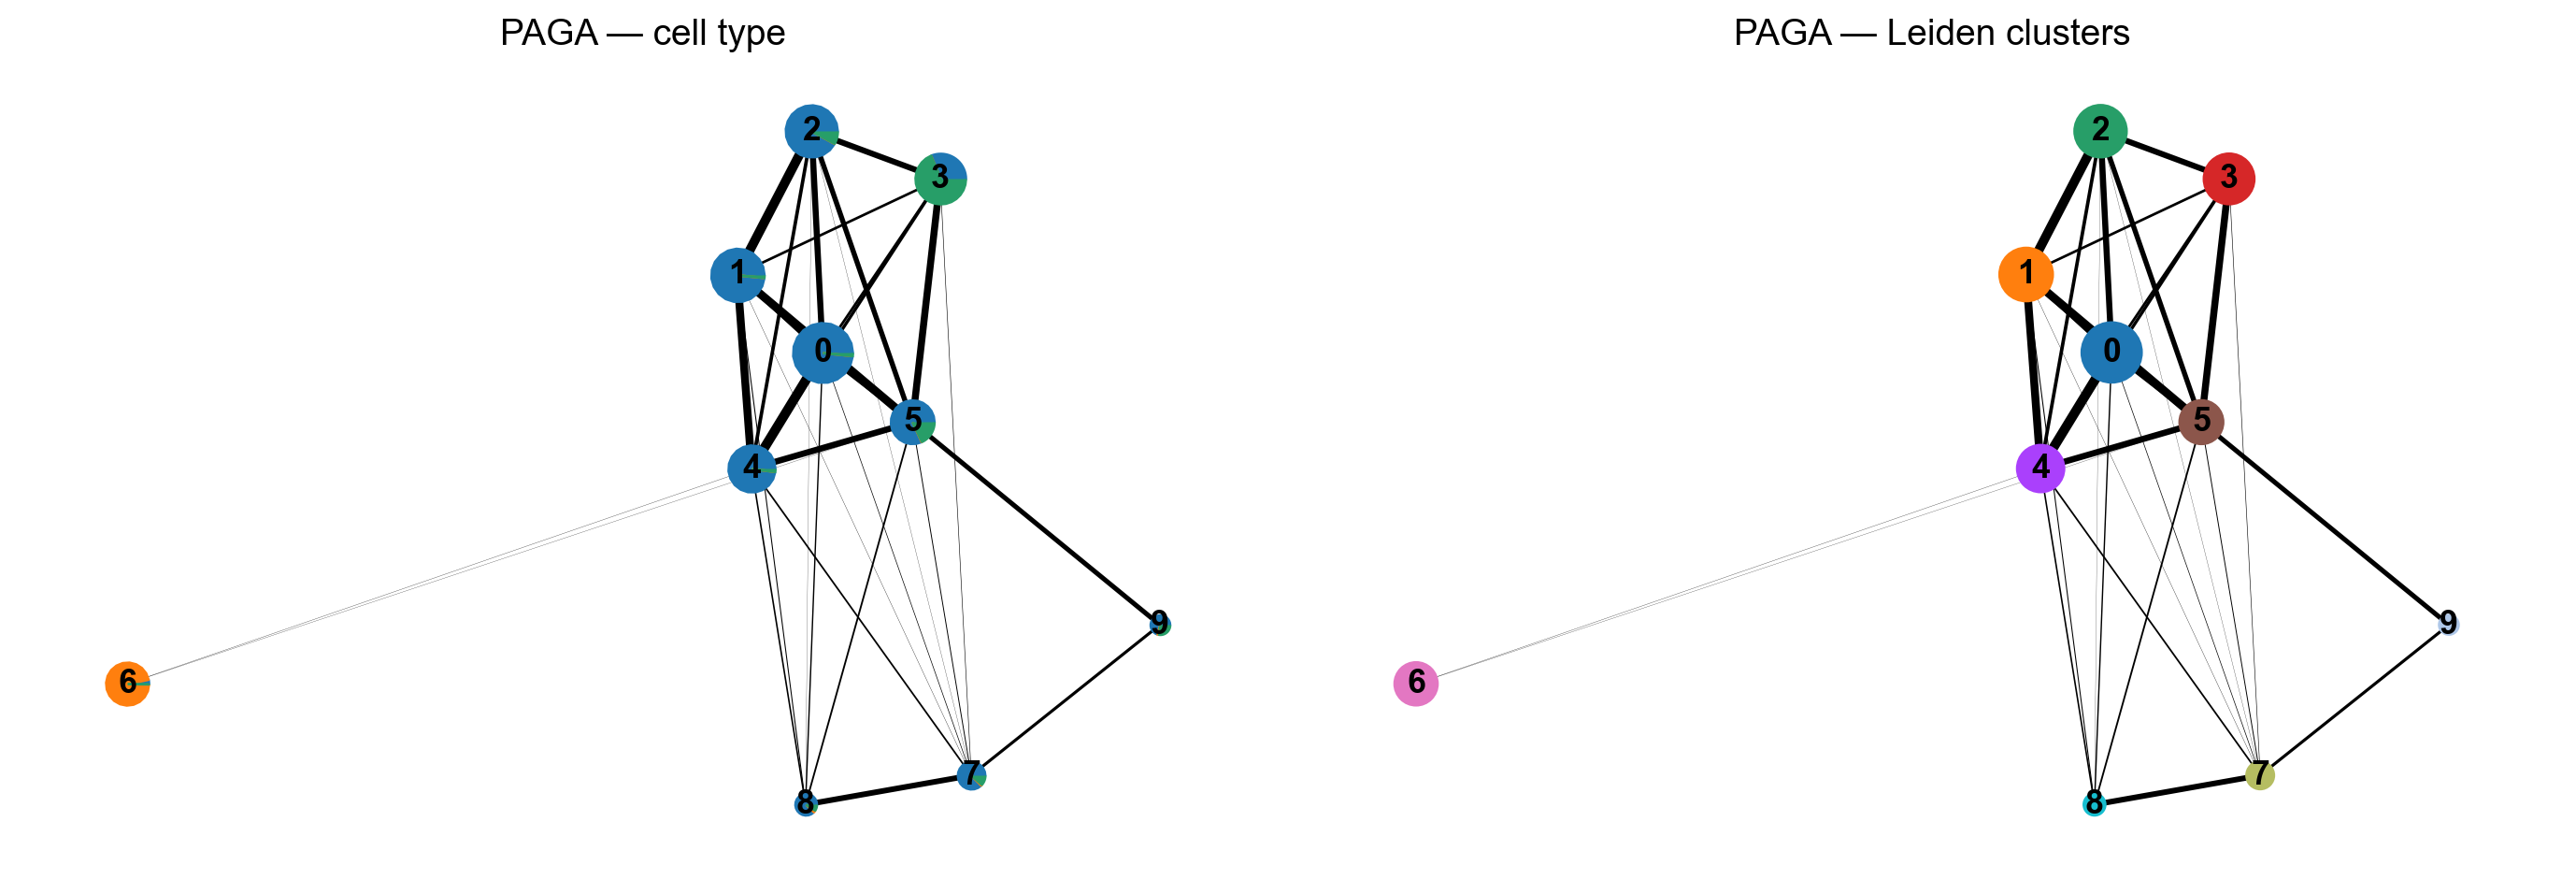

In [13]:
LEIDEN_RESOLUTION = 0.5   # increase if outlier clusters merge with main FAPs
PAGA_THRESHOLD    = 0.05  # minimum PAGA edge weight to count as "connected"

sc.tl.leiden(
    adata, resolution=LEIDEN_RESOLUTION,
    neighbors_key="neighbors_harmony", key_added="leiden_coarse",
    random_state=42,
)
sc.tl.paga(adata, groups="leiden_coarse", neighbors_key="neighbors_harmony")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sc.pl.paga(adata, color="cell_type_", ax=axes[0], show=False,
           title="PAGA — cell type", node_size_scale=2)
sc.pl.paga(adata, color="leiden_coarse", ax=axes[1], show=False,
           title="PAGA — Leiden clusters", node_size_scale=2)
plt.tight_layout()
plt.savefig(f"{BASE_OUT}/paga_overview.png", bbox_inches="tight", dpi=150)
plt.show()

In [14]:
# Inspect cell-type composition per Leiden cluster
ct_frac = (
    adata.obs.groupby("leiden_coarse")["cell_type_"]
    .value_counts(normalize=True)
    .unstack(fill_value=0)
    .round(2)
)
ct_frac["n_cells"] = adata.obs["leiden_coarse"].value_counts().reindex(ct_frac.index)
display(ct_frac.style.background_gradient(cmap="Blues", subset=["FAPs", "Pre_adipocytes"])
             .set_caption("Cell-type fraction per Leiden cluster"))

cell_type_,FAPs,Myofibroblasts,Pre_adipocytes,n_cells
leiden_coarse,,,,
0,0.980000,0.000000,0.020000,3988
1,0.990000,0.000000,0.010000,2487
2,0.920000,0.000000,0.080000,2276
3,0.310000,0.000000,0.690000,2010
4,0.980000,0.000000,0.020000,1509
5,0.820000,0.000000,0.180000,1120
6,0.030000,0.970000,0.000000,1052
7,0.870000,0.010000,0.110000,175
8,0.880000,0.030000,0.090000,66


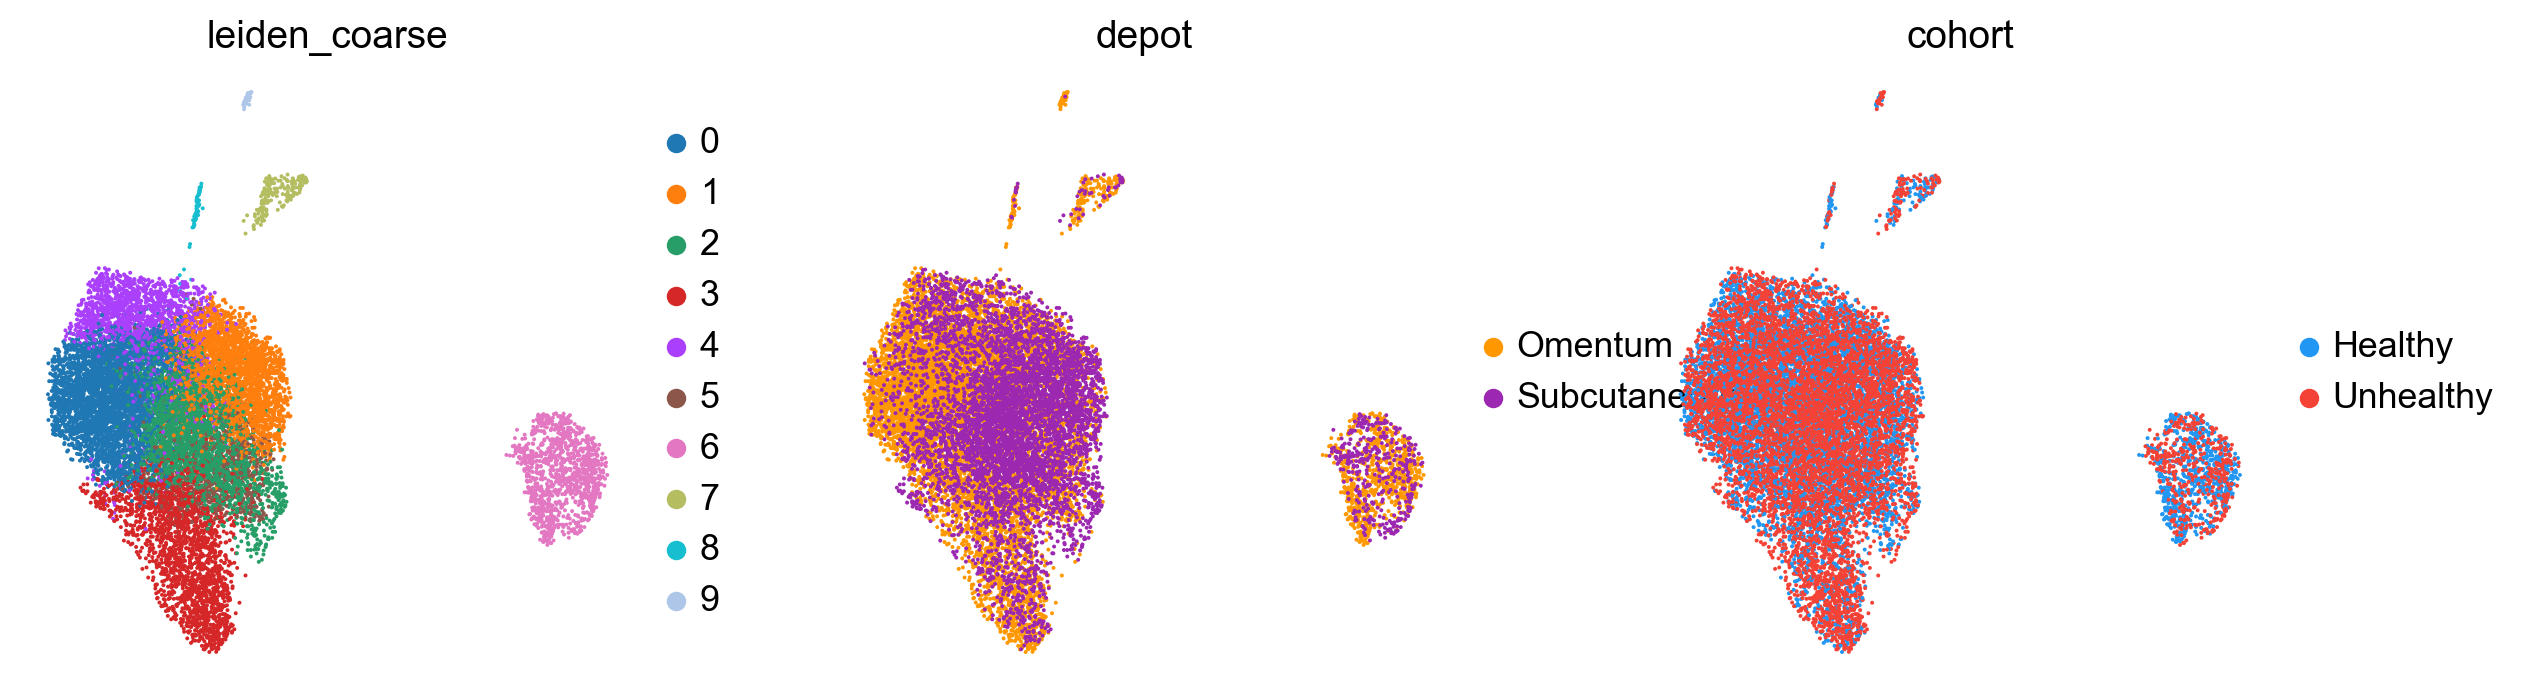

In [15]:
sc.pl.umap(adata, color=["leiden_coarse", "depot", "cohort"])

In [16]:
# Identify Pre_adipocyte and FAP clusters
preadip_clusters = ct_frac.index[ct_frac["Pre_adipocytes"] > 0.3].tolist()
fap_clusters_all = ct_frac.index[ct_frac["FAPs"] > 0.5].tolist()
print(f"Pre_adipocyte-dominant clusters : {preadip_clusters}")
print(f"FAP-dominant clusters (all)     : {fap_clusters_all}")

# Keep only FAP clusters with a PAGA edge to a Pre_adipocyte cluster
paga_conn   = adata.uns["paga"]["connectivities"].toarray()
leiden_cats = list(adata.obs["leiden_coarse"].cat.categories)

connected_fap_clusters = [
    fc for fc in fap_clusters_all
    if any(
        max(paga_conn[leiden_cats.index(fc), leiden_cats.index(pc)],
            paga_conn[leiden_cats.index(pc), leiden_cats.index(fc)]) > PAGA_THRESHOLD
        for pc in preadip_clusters
    )
]
dropped_fap_clusters = [c for c in fap_clusters_all if c not in connected_fap_clusters]

print(f"\nFAP clusters connected to Pre_adipocytes : {connected_fap_clusters}")
print(f"FAP clusters to DROP (not connected)     : {dropped_fap_clusters}")

Pre_adipocyte-dominant clusters : ['3']
FAP-dominant clusters (all)     : ['0', '1', '2', '4', '5', '7', '8', '9']

FAP clusters connected to Pre_adipocytes : ['0', '1', '2', '4', '5']
FAP clusters to DROP (not connected)     : ['7', '8', '9']


⚠️ **Check the output above** before proceeding.
- If `connected_fap_clusters` is empty, lower `PAGA_THRESHOLD` (try 0.01).
- If too many cells are dropped, lower `LEIDEN_RESOLUTION` (try 0.3) so fewer clusters form.
- If the main FAP body splits across clusters, raise `LEIDEN_RESOLUTION`.

In [17]:
adata_full = adata.copy()

In [24]:
keep = set(ct_frac.index).difference(dropped_fap_clusters)
n_before = adata.n_obs
adata = adata[adata.obs["leiden_coarse"].isin(keep)].copy()
print(f"\nRemoved {n_before - adata.n_obs} cells  |  Retained {adata.n_obs} cells")


Removed 285 cells  |  Retained 14442 cells


## 5b. Characterising removed clusters

What are the cells we just dropped?  
Three angles: cohort/depot/sex balance, UMAP localisation, and marker genes vs the retained FAPs.

Removed cells : 343  (2.5% of pre-filter total)
  Leiden clusters: ['6', '8']



,n_cells,pct_FAPs
leiden_coarse,,
0,0,NaN
1,0,NaN
2,0,NaN
3,0,NaN
4,0,NaN
5,0,NaN
6,302,90.1
7,0,NaN
8,41,70.7


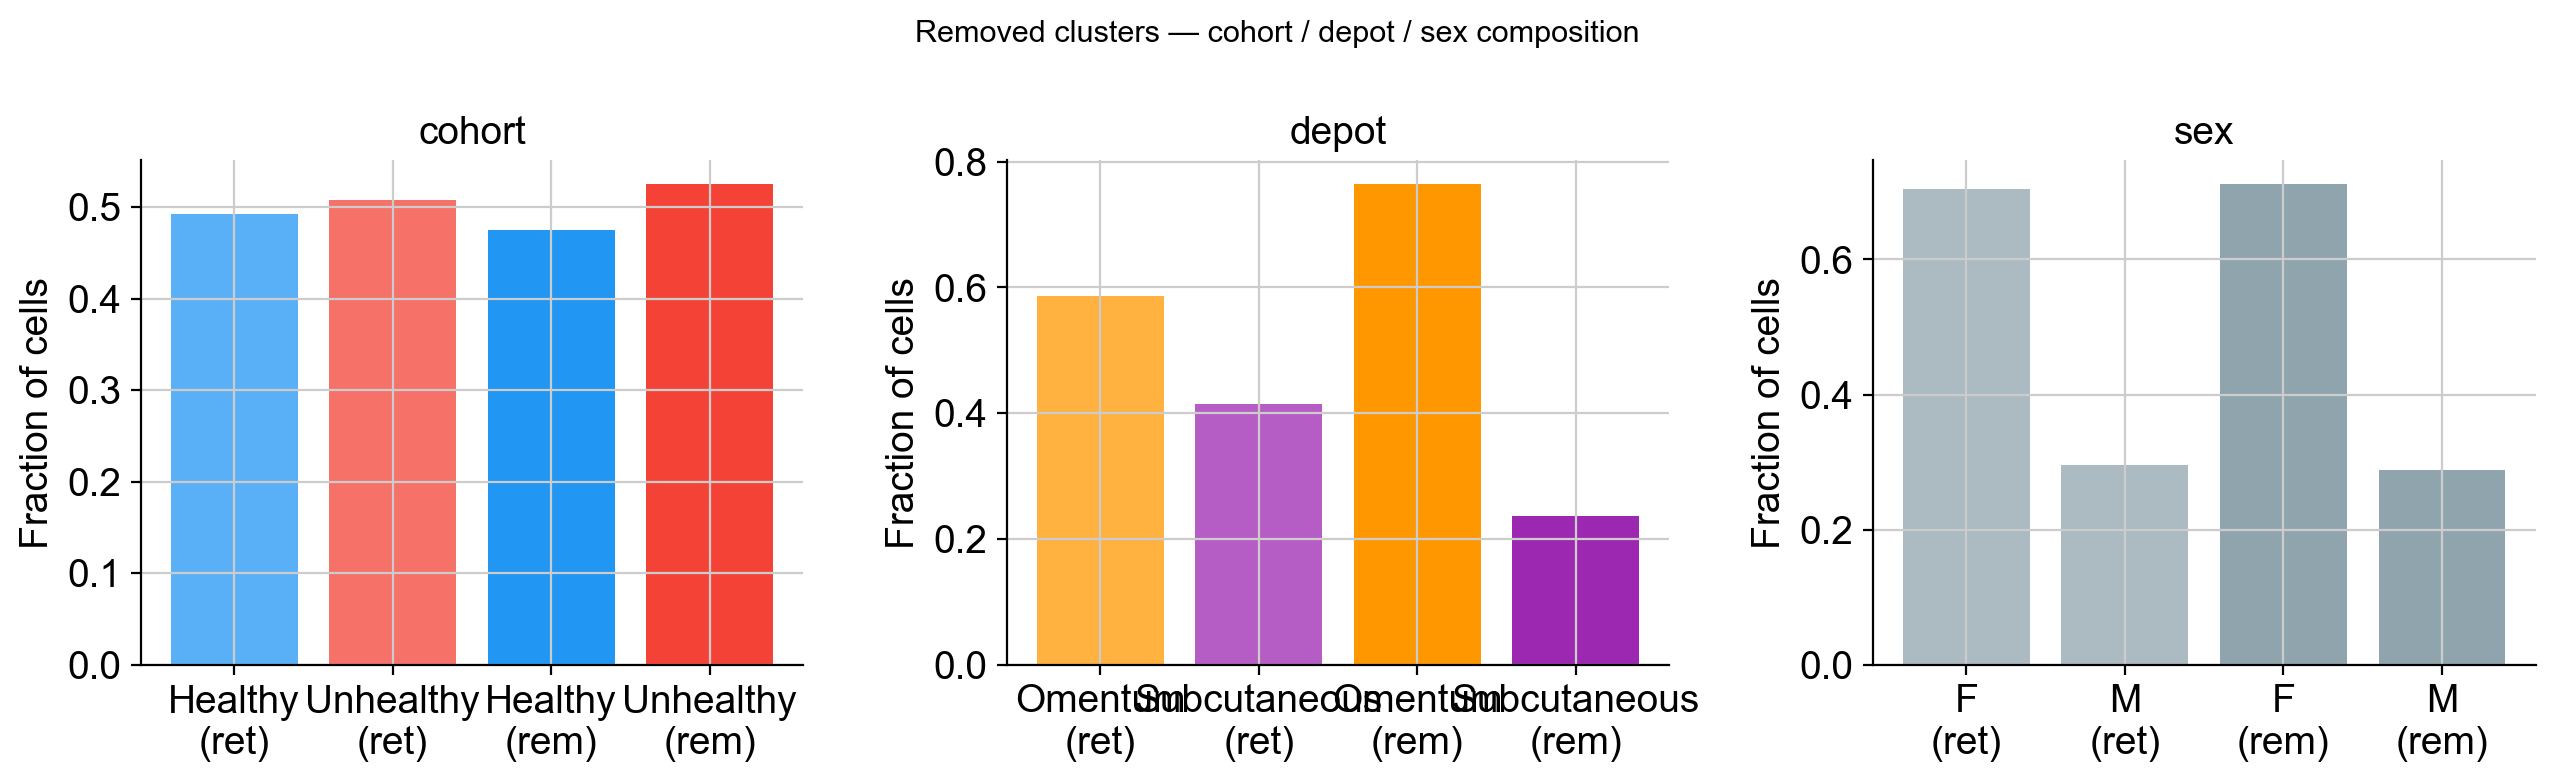

In [20]:
# Label every cell in the pre-filter snapshot as retained or removed
adata_full.obs["fap_status"] = "retained"
adata_full.obs.loc[
    adata_full.obs["leiden_coarse"].isin(dropped_fap_clusters), "fap_status"
] = "removed"

removed = adata_full[adata_full.obs["fap_status"] == "removed"]
print(f"Removed cells : {removed.n_obs}  ({100*removed.n_obs/adata_full.n_obs:.1f}% of pre-filter total)")
print(f"  Leiden clusters: {dropped_fap_clusters}\n")

# Size and cell-type purity of each dropped cluster
dropped_summary = (
    adata_full.obs[adata_full.obs["leiden_coarse"].isin(dropped_fap_clusters)]
    .groupby("leiden_coarse")
    .agg(
        n_cells=("cell_type_", "count"),
        pct_FAPs=("cell_type_", lambda x: (x == "FAPs").mean() * 100),
    )
    .round(1)
)
display(dropped_summary)

# Cohort / depot / sex balance
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
fig.suptitle("Removed clusters — cohort / depot / sex composition", fontsize=11)

for ax, col in zip(axes, ["cohort", "depot", "sex"]):
    # Stacked bars: removed vs retained, normalised to fractions
    for status, ls in [("retained", "--"), ("removed", "-")]:
        subset = adata_full.obs[adata_full.obs["fap_status"] == status]
        counts = subset[col].value_counts(normalize=True).sort_index()
        ax.bar(
            [f"{c}\n({status[:3]})" for c in counts.index],
            counts.values,
            color=[COLORS.get(c, "#90A4AE") for c in counts.index],
            alpha=0.75 if status == "retained" else 1.0,
            label=status,
        )
    ax.set_ylabel("Fraction of cells")
    ax.set_title(col)
    ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

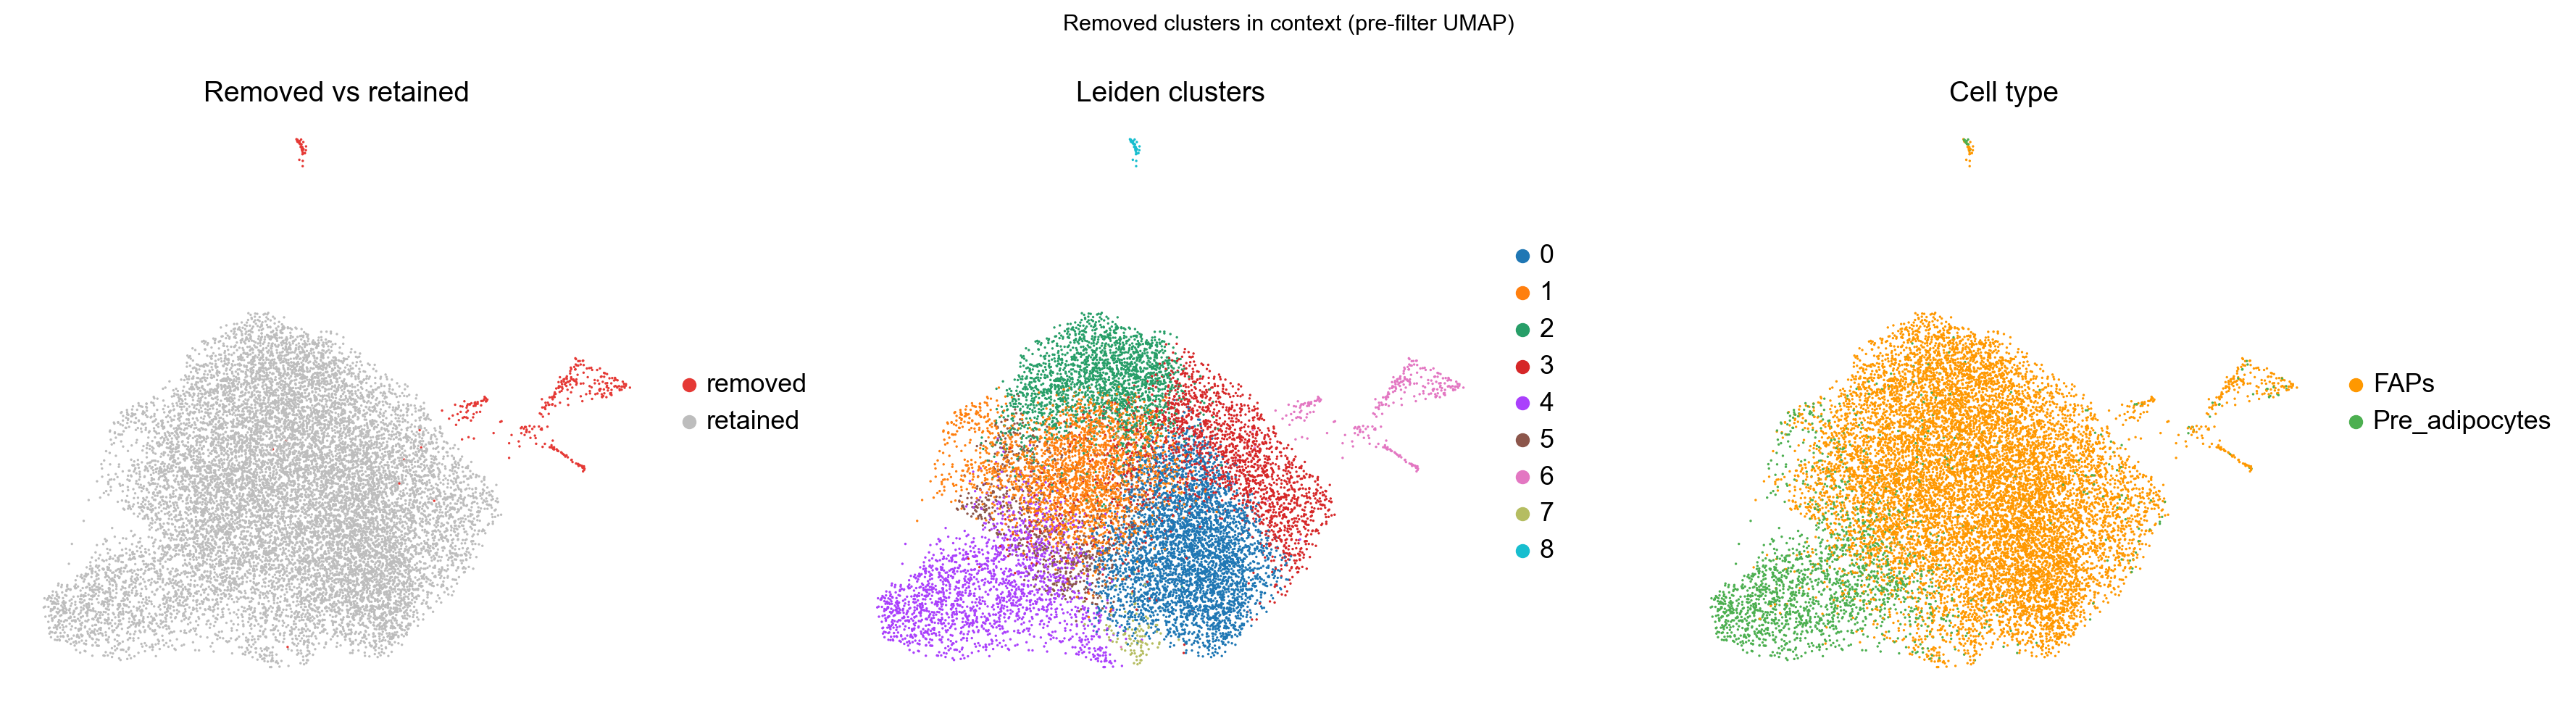

In [21]:
# UMAP of all pre-filter cells, highlighting removed clusters.
# Compute a temporary UMAP on adata_full (uses the Harmony neighbours already present).
sc.tl.umap(adata_full, neighbors_key="neighbors_harmony")

status_palette = {"retained": "#BDBDBD", "removed": "#E53935"}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Removed clusters in context (pre-filter UMAP)", fontsize=11)

# Panel 1: removed vs retained
sc.pl.umap(adata_full, color="fap_status", ax=axes[0], show=False,
           palette=status_palette, title="Removed vs retained",
           size=6, legend_loc="right margin")

# Panel 2: Leiden clusters — so you can cross-reference cluster numbers
sc.pl.umap(adata_full, color="leiden_coarse", ax=axes[1], show=False,
           title="Leiden clusters", size=6, legend_loc="right margin")

# Panel 3: cell type — confirm removed cells are FAPs
sc.pl.umap(adata_full, color="cell_type_", ax=axes[2], show=False,
           title="Cell type", size=6,
           palette={"FAPs": "#FF9800", "Pre_adipocytes": "#4CAF50"},
           legend_loc="right margin")

plt.tight_layout()
plt.savefig(f"{BASE_OUT}/removed_clusters_umap.png", bbox_inches="tight", dpi=150)
plt.show()

Top markers of removed FAP clusters (vs retained, log2FC > 0.5, p < 0.05):


,names,logfoldchanges,pvals_adj,scores
0,SRGN,3.796,0.0,17.763000
1,HLA-B,1.633,0.0,16.903999
2,B2M,0.849,0.0,16.089001
3,PTPRC,5.289,0.0,15.163000
4,CXCR4,4.436,0.0,15.025000
5,CD69,4.128,0.0,13.578000
6,HLA-C,1.141,0.0,13.324000
7,ARHGDIB,2.781,0.0,13.054000
8,BTG1,1.276,0.0,13.048000
9,EZR,3.816,0.0,12.550000


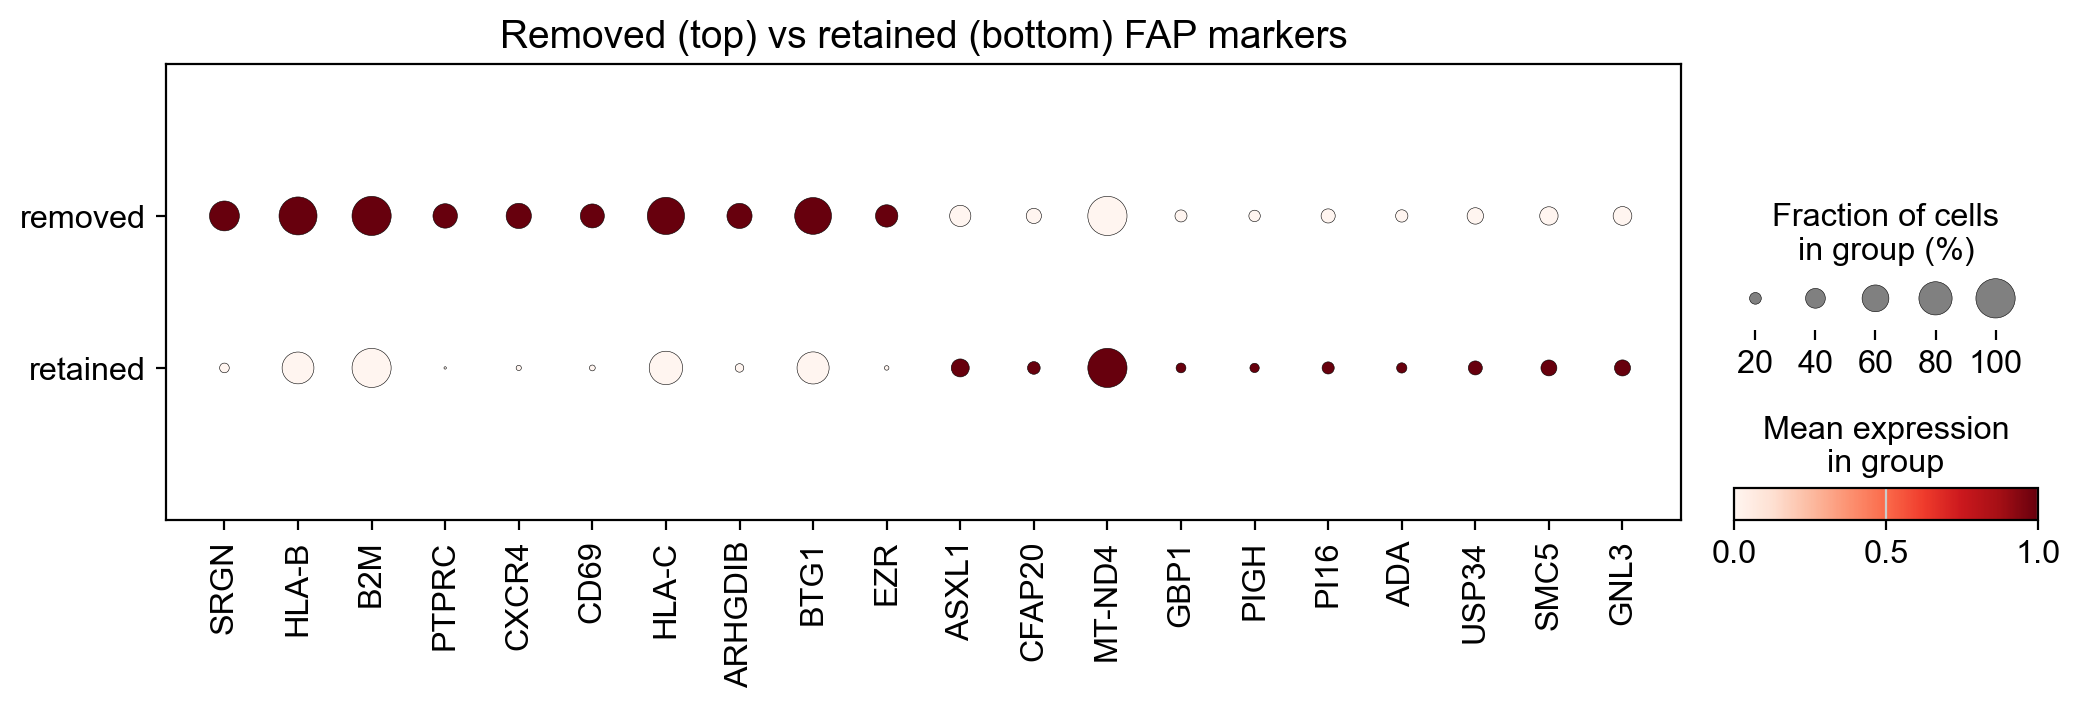

In [22]:
# Marker genes: removed FAPs vs retained FAPs (Wilcoxon, logcounts)
fap_full = adata_full[adata_full.obs["cell_type_"] == "FAPs"].copy()
fap_full.X = fap_full.layers["logcounts"].copy()

sc.tl.rank_genes_groups(
    fap_full, groupby="fap_status",
    groups=["removed"], reference="retained",
    method="wilcoxon", use_raw=False,
    key_added="markers_removed_vs_retained",
)

# Top markers table
markers_df = sc.get.rank_genes_groups_df(
    fap_full, group="removed", key="markers_removed_vs_retained",
    pval_cutoff=0.05, log2fc_min=0.5,
).head(20)
print(f"Top markers of removed FAP clusters (vs retained, log2FC > 0.5, p < 0.05):")
display(markers_df[["names", "logfoldchanges", "pvals_adj", "scores"]].round(3))

# Dot plot of top markers
top_up   = sc.get.rank_genes_groups_df(
    fap_full, group="removed", key="markers_removed_vs_retained",
).query("logfoldchanges > 0").head(10)["names"].tolist()

top_down = sc.get.rank_genes_groups_df(
    fap_full, group="removed", key="markers_removed_vs_retained",
).query("logfoldchanges < 0").head(10)["names"].tolist()

genes_to_plot = top_up + top_down
if genes_to_plot:
    sc.pl.dotplot(
        fap_full, var_names=genes_to_plot, groupby="fap_status",
        use_raw=False, standard_scale="var",
        title="Removed (top) vs retained (bottom) FAP markers",
        figsize=(max(10, len(genes_to_plot) * 0.6), 3),
    )

## 8. Diffusion map + pseudotime (DPT)

**Root selection strategy:** project all FAP cells onto the direction vector pointing
from the FAP centroid toward the Pre_adipocyte centroid in diffusion space.
The FAP with the **lowest projection** is the most upstream / progenitor-like cell
and becomes the root.  This avoids the centroid trick that can land on an intermediate
cell, and explicitly aligns the pseudotime axis with the FAP → Pre_adipocyte direction.

In [25]:
sc.tl.diffmap(adata, neighbors_key="neighbors_harmony", n_comps=15)

fap_mask     = adata.obs["cell_type_"].values == "FAPs"
preadip_mask = adata.obs["cell_type_"].values == "Pre_adipocytes"

fap_dc     = adata.obsm["X_diffmap"][fap_mask]
preadip_dc = adata.obsm["X_diffmap"][preadip_mask]

# Direction vector: FAP centroid → Pre_adipocyte centroid
direction = preadip_dc.mean(0) - fap_dc.mean(0)
direction = direction / np.linalg.norm(direction)

# Root = FAP with lowest projection onto this direction (most upstream)
projections = fap_dc @ direction
root_idx    = int(np.where(fap_mask)[0][np.argmin(projections)])

adata.uns["iroot"] = root_idx
sc.tl.dpt(adata, n_dcs=10, neighbors_key="neighbors_harmony")

print(f"Root cell index : {root_idx}")
print(f"Root cell type  : {adata.obs['cell_type_'].iloc[root_idx]}")

Root cell index : 12749
Root cell type  : FAPs


In [26]:
# Sanity check: Pre_adipocytes should have higher median pseudotime than FAPs
for grp in ["cell_type_", "cohort", "depot"]:
    display(
        adata.obs.groupby(grp)["dpt_pseudotime"]
            .describe()[["mean", "std", "50%"]]
            .rename(columns={"50%": "median"})
            .style.background_gradient(cmap="viridis", subset=["mean", "median"])
            .set_caption(f"Pseudotime by {grp}")
    )

,mean,std,median
cell_type_,,,
FAPs,0.030993,0.039001,0.028606
Myofibroblasts,0.824919,0.091331,0.829968
Pre_adipocytes,0.053806,0.029719,0.045456


,mean,std,median
cohort,,,
Healthy,0.101966,0.227661,0.029524
Unhealthy,0.078181,0.184254,0.029746


,mean,std,median
depot,,,
Omentum,0.098055,0.217629,0.030347
Subcutaneous,0.078595,0.191302,0.028485


## 9. Pseudotime UMAP

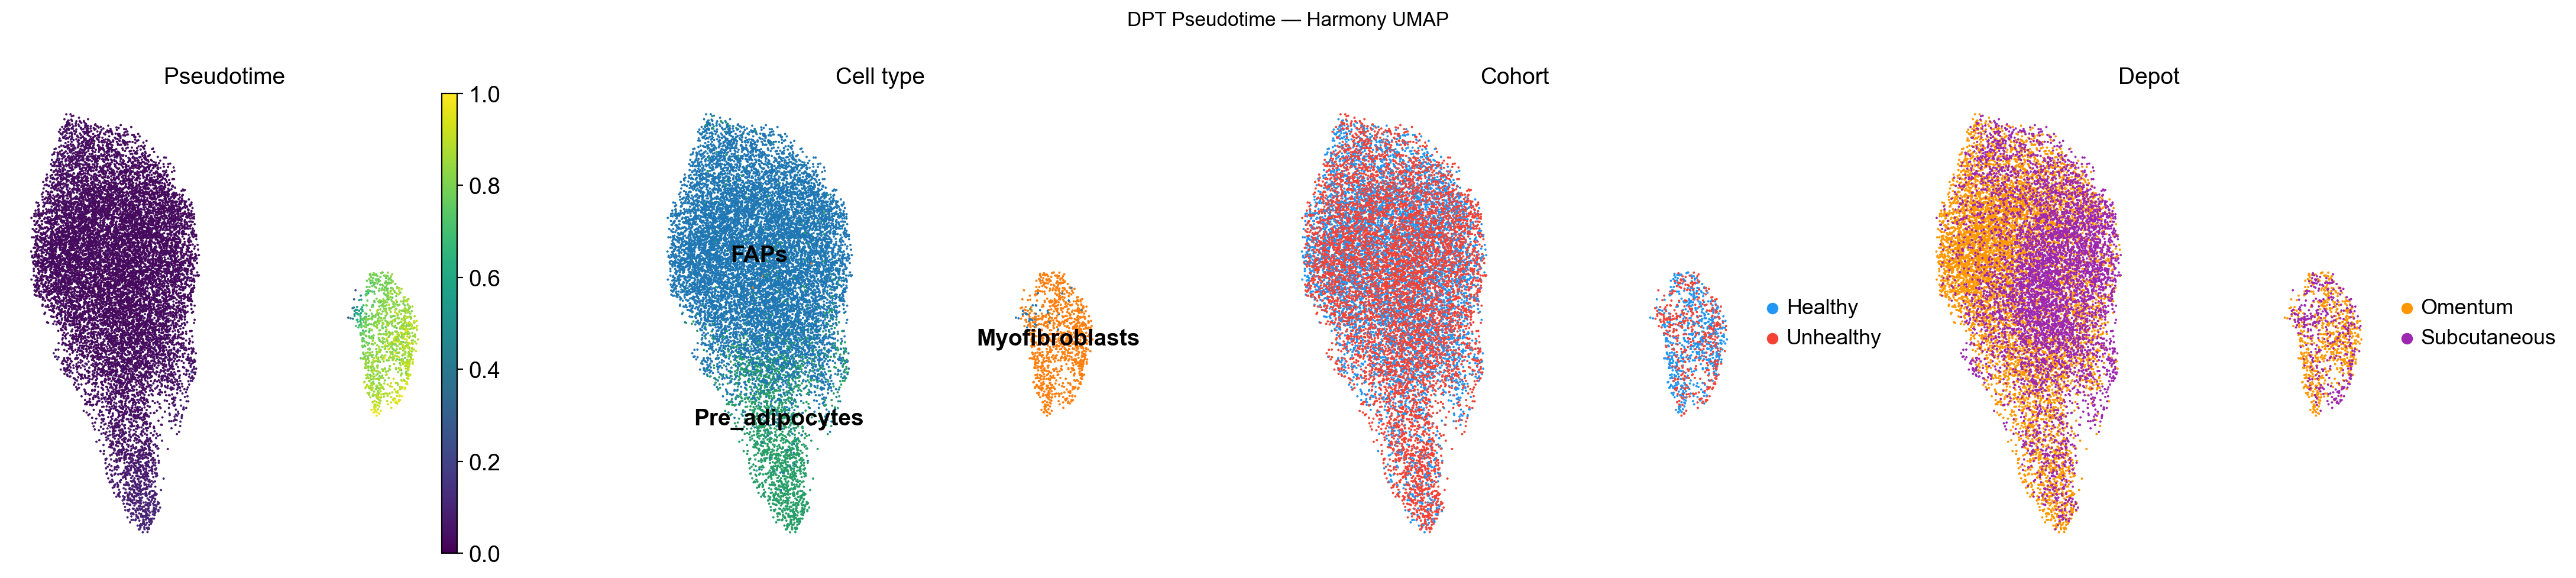

In [27]:
fig, axes = plt.subplots(1, 4, figsize=(22, 5))
fig.suptitle("DPT Pseudotime — Harmony UMAP", fontsize=12)

for ax, (color, title) in zip(axes, [
    ("dpt_pseudotime", "Pseudotime"),
    ("cell_type_",     "Cell type"),
    ("cohort",         "Cohort"),
    ("depot",          "Depot"),
]):
    sc.pl.embedding(
        adata, basis="umap_harmony", color=color, ax=ax, show=False,
        title=title, frameon=False,
        color_map="viridis" if color == "dpt_pseudotime" else None,
        palette=PALETTE.get(color),
        legend_loc="on data" if color == "cell_type_" else "right margin",
        size=8,
    )

plt.tight_layout()
plt.savefig(f"{BASE_OUT}/umap_pseudotime.pdf", bbox_inches="tight", dpi=150)
plt.savefig(f"{BASE_OUT}/umap_pseudotime.png", bbox_inches="tight", dpi=150)
plt.show()

## 10. Pseudotime distributions by group

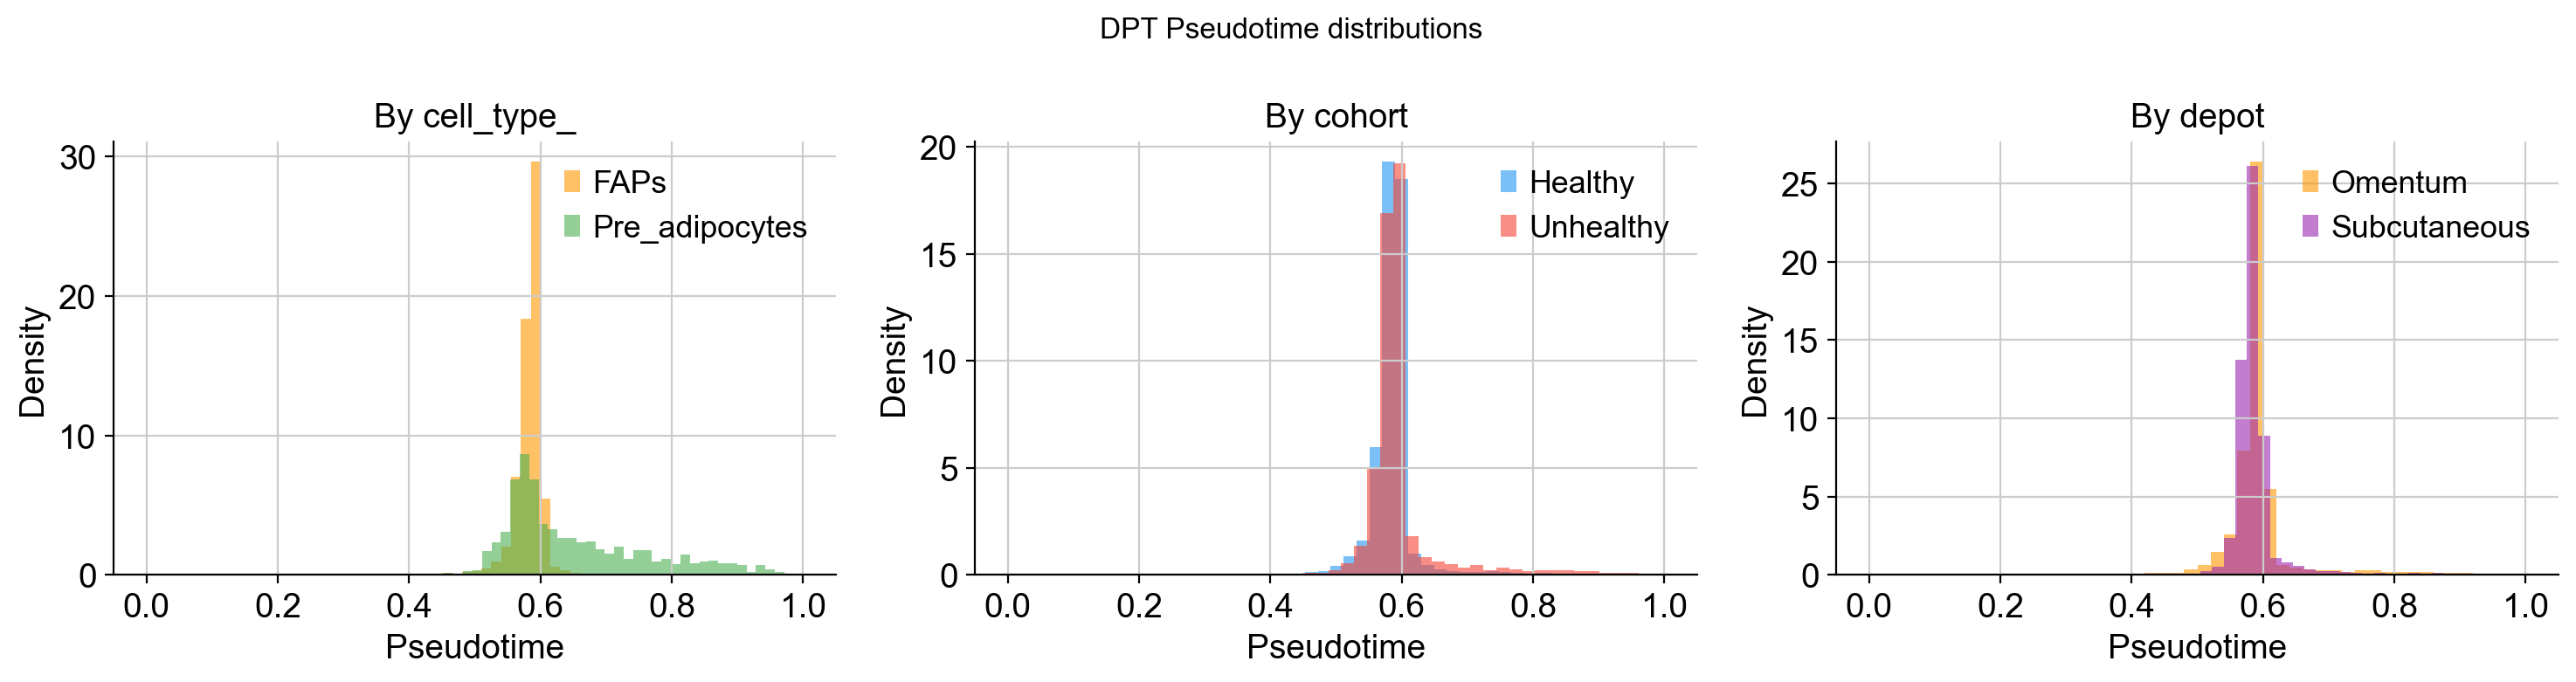

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("DPT Pseudotime distributions", fontsize=12)

for ax, grp in zip(axes, ["cell_type_", "cohort", "depot"]):
    for cat in sorted(adata.obs[grp].unique()):
        vals = adata.obs.loc[adata.obs[grp] == cat, "dpt_pseudotime"]
        ax.hist(vals, bins=50, density=True, alpha=0.6,
                label=cat, color=COLORS.get(cat))
    ax.set_xlabel("Pseudotime")
    ax.set_ylabel("Density")
    ax.set_title(f"By {grp}")
    ax.legend(frameon=False)
    ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig(f"{BASE_OUT}/pseudotime_distributions.pdf", bbox_inches="tight", dpi=150)
plt.savefig(f"{BASE_OUT}/pseudotime_distributions.png", bbox_inches="tight", dpi=150)
plt.show()

## 11. Save processed object for R (tradeSeq)

In [34]:
# Restore logcounts to .X so zellkonverter reads it as normalised expression
adata.X = adata.layers["logcounts"].copy()

out_path = f"{BASE_OUT}/fap_preadip_processed.h5ad"
adata.write_h5ad(out_path)

print(f"Saved → {out_path}")
print(f"  Shape    : {adata.shape}")
print(f"  obsm keys: {list(adata.obsm.keys())}")
print(f"  layers   : {list(adata.layers.keys())}")
print("\nNext step: pseudotime_02_tradeseq.R")

Saved → /Users/willtrim/Documents/projs/Wills_analysis/obesity_scRNAseq/outputs/pseudotime/myo/fap_preadip_processed.h5ad
  Shape    : (14442, 22410)
  obsm keys: ['X_pca', 'X_umap', 'X_pca_harmony', 'X_umap_noint', 'X_umap_harmony', 'X_draw_graph_fa', 'X_diffmap']
  layers   : ['counts', 'logcounts']

Next step: pseudotime_02_tradeseq.R
